e:\ViT MLDC\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
Classes: ['Anthracnose', 'Bacterial Canker', 'Cutting Weevil', 'Die Back', 'Gall Midge', 'Healthy', 'Powdery Mildew', 'Sooty Mould']
Train: 2800  Val: 600  Test: 600
Extracting features...


100%|██████████| 600/600 [00:12<00:00, 46.39it/s]


Feature shapes: Train: (2800, 768) Val: (600, 768) Test: (600, 768)
Epoch 1/10 - Train Loss: 1.8209  Val Loss: 1.5993
Epoch 2/10 - Train Loss: 1.4380  Val Loss: 1.2778
Epoch 3/10 - Train Loss: 1.1542  Val Loss: 1.0431
Epoch 4/10 - Train Loss: 0.9438  Val Loss: 0.8730
Epoch 5/10 - Train Loss: 0.7906  Val Loss: 0.7465
Epoch 6/10 - Train Loss: 0.6819  Val Loss: 0.6495
Epoch 7/10 - Train Loss: 0.5903  Val Loss: 0.5749
Epoch 8/10 - Train Loss: 0.5270  Val Loss: 0.5131
Epoch 9/10 - Train Loss: 0.4647  Val Loss: 0.4648
Epoch 10/10 - Train Loss: 0.4189  Val Loss: 0.4230

Test Metrics: Accuracy=0.9500, Precision=0.9517, Recall=0.9500, F1=0.9499

Running t-SNE on raw test images (pixels)...


100%|██████████| 600/600 [00:01<00:00, 459.00it/s]



Running t-SNE on Tiny Swin V2 features...

Running t-SNE on Classifier Head outputs...


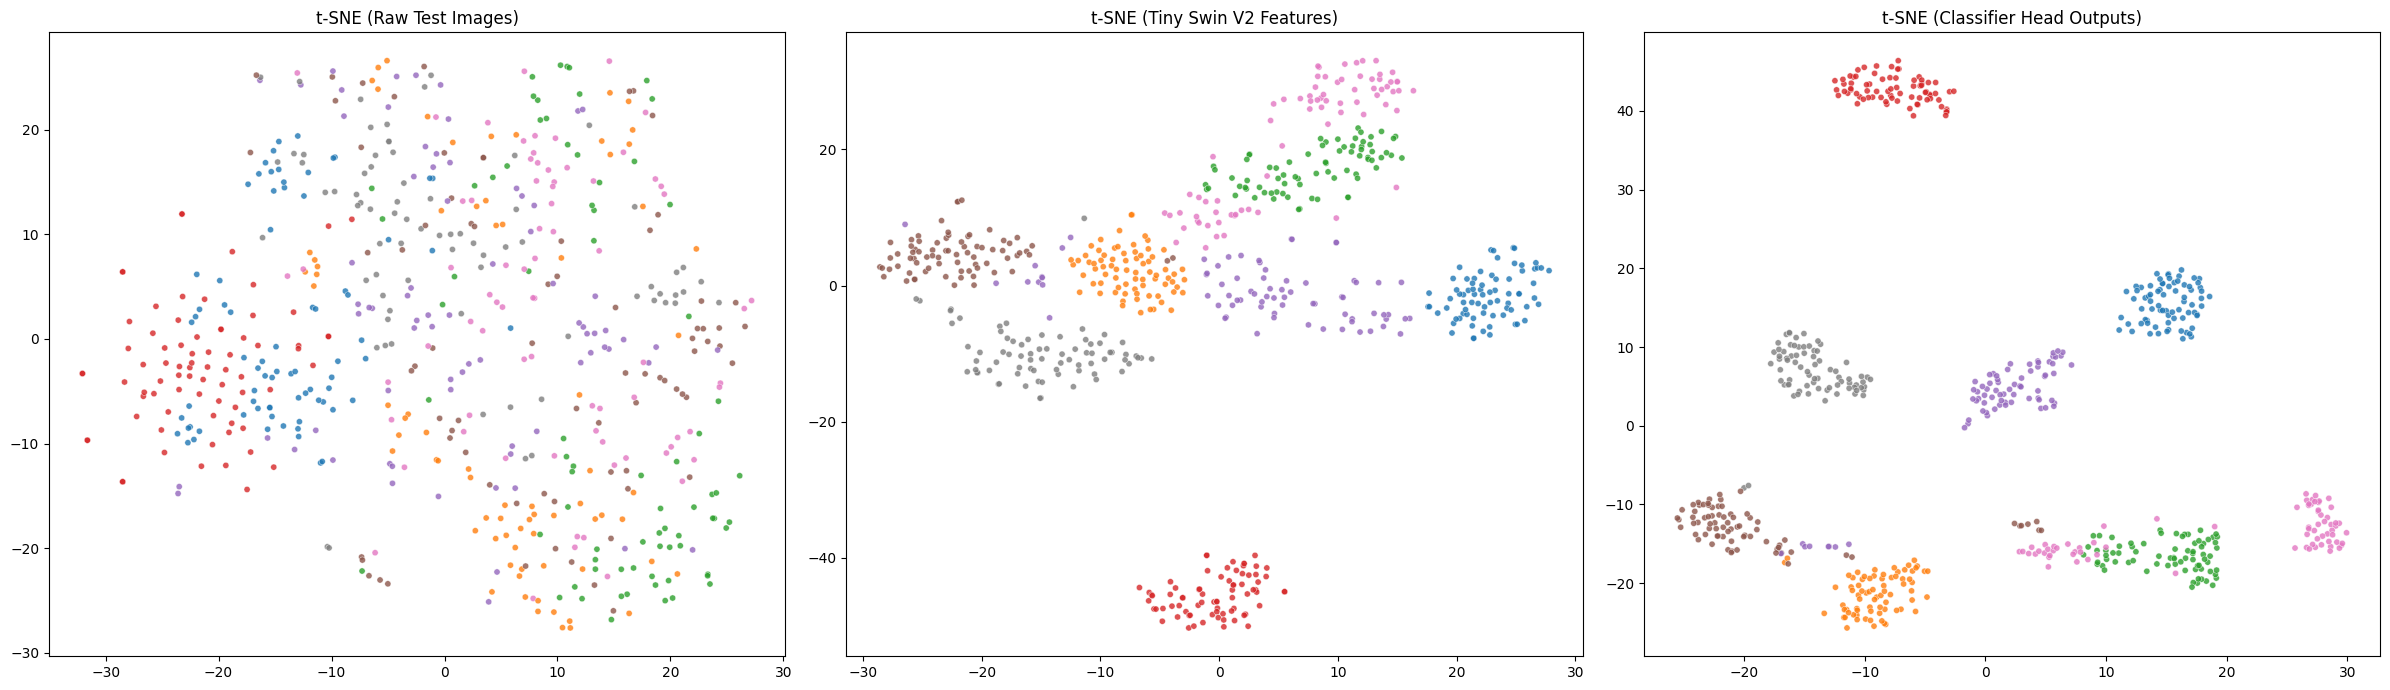

In [1]:
# =========================
# Imports & Device Setup
# =========================
import os, glob, random
import numpy as np
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torchvision import transforms
import timm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.manifold import TSNE

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Seed for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# =========================
# Dataset Paths & Split
# =========================
DATASET_DIR = r"E:\ViT MLDC\dataset"
IMG_SIZE = 224

CLASS_NAMES = sorted([d for d in os.listdir(DATASET_DIR) if os.path.isdir(os.path.join(DATASET_DIR, d))])
print("Classes:", CLASS_NAMES)

image_paths, labels = [], []
for lbl in CLASS_NAMES:
    folder = os.path.join(DATASET_DIR, lbl)
    imgs = glob.glob(os.path.join(folder, '*.jpg')) + glob.glob(os.path.join(folder, '*.png'))
    image_paths.extend(imgs)
    labels.extend([lbl]*len(imgs))

le = LabelEncoder()
labels_encoded = le.fit_transform(labels)

# 70:15:15 split
X_train_paths, X_temp_paths, y_train, y_temp = train_test_split(
    image_paths, labels_encoded, stratify=labels_encoded, test_size=0.3, random_state=42
)
X_val_paths, X_test_paths, y_val, y_test = train_test_split(
    X_temp_paths, y_temp, stratify=y_temp, test_size=0.5, random_state=42
)
print(f"Train: {len(X_train_paths)}  Val: {len(X_val_paths)}  Test: {len(X_test_paths)}")

# =========================
# Transforms
# =========================
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

# =========================
# Feature Extractor (Tiny Swin V2)
# =========================
model_name = 'swin_tiny_patch4_window7_224'
feature_model = timm.create_model(model_name, pretrained=True, num_classes=0)
feature_model.eval().to(device)

@torch.no_grad()
def extract_feature_from_path(path, transform):
    img = Image.open(path).convert('RGB')
    x = transform(img).unsqueeze(0).to(device)
    feat = feature_model(x)
    return feat.squeeze(0).cpu().numpy()

print("Extracting features...")
X_train_feats = np.stack([extract_feature_from_path(p, train_transform) for p in tqdm(X_train_paths)])
X_val_feats   = np.stack([extract_feature_from_path(p, val_transform) for p in tqdm(X_val_paths)])
X_test_feats  = np.stack([extract_feature_from_path(p, val_transform) for p in tqdm(X_test_paths)])

print("Feature shapes: Train:", X_train_feats.shape, "Val:", X_val_feats.shape, "Test:", X_test_feats.shape)

# =========================
# LoRA-adapted Classifier Head
# =========================
class LoRALinear(nn.Module):
    def __init__(self, in_features, out_features, r=4):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features, bias=False)
        self.lora_a = nn.Linear(in_features, r, bias=False)
        self.lora_b = nn.Linear(r, out_features, bias=False)
    def forward(self, x):
        return self.linear(x) + self.lora_b(self.lora_a(x))

class ViTHead(nn.Module):
    def __init__(self, in_features, num_classes, dropout_rate=0.4):
        super().__init__()
        self.dropout = nn.Dropout(dropout_rate)
        self.head = LoRALinear(in_features, num_classes, r=4)
    def forward(self, x):
        if x.dim() == 1:
            x = x.unsqueeze(0)
            return self.head(self.dropout(x)).squeeze(0)
        return self.head(self.dropout(x))

in_features = X_train_feats.shape[1]
num_classes = len(CLASS_NAMES)
model_head = ViTHead(in_features=in_features, num_classes=num_classes, dropout_rate=0.4).to(device)

# =========================
# Loss & Optimizer
# =========================
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_head.parameters(), lr=1e-4)

# =========================
# Dataloaders
# =========================
batch_size = 64
train_loader = DataLoader(TensorDataset(torch.tensor(X_train_feats, dtype=torch.float32),
                                        torch.tensor(y_train, dtype=torch.long)),
                          batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(torch.tensor(X_val_feats, dtype=torch.float32),
                                      torch.tensor(y_val, dtype=torch.long)),
                        batch_size=batch_size, shuffle=False)
test_loader = DataLoader(TensorDataset(torch.tensor(X_test_feats, dtype=torch.float32),
                                       torch.tensor(y_test, dtype=torch.long)),
                         batch_size=batch_size, shuffle=False)

# =========================
# Training Loop
# =========================
EPOCHS = 10
for epoch in range(EPOCHS):
    model_head.train()
    total_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model_head(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
    epoch_loss = total_loss / len(train_loader.dataset)

    # Validation
    model_head.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model_head(xb)
            loss = criterion(logits, yb)
            val_loss += loss.item() * xb.size(0)
    val_loss /= len(val_loader.dataset)

    print(f"Epoch {epoch+1}/{EPOCHS} - Train Loss: {epoch_loss:.4f}  Val Loss: {val_loss:.4f}")

# =========================
# Evaluation
# =========================
model_head.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        outputs = model_head(xb)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        y_true.extend(yb.numpy())
        y_pred.extend(preds)

accuracy = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro")
print(f"\nTest Metrics: Accuracy={accuracy:.4f}, Precision={precision:.4f}, Recall={recall:.4f}, F1={f1:.4f}")

# =========================
# t-SNE Visualizations
# =========================

print("\nRunning t-SNE on raw test images (pixels)...")
raw_imgs = []
for p in tqdm(X_test_paths):
    img = Image.open(p).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
    arr = np.array(img).reshape(-1) / 255.0   # flatten
    raw_imgs.append(arr)
raw_imgs = np.array(raw_imgs)
tsne_raw = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000).fit_transform(raw_imgs)

print("\nRunning t-SNE on Tiny Swin V2 features...")
tsne_proc = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000).fit_transform(X_test_feats)

print("\nRunning t-SNE on Classifier Head outputs...")
with torch.no_grad():
    test_logits = []
    for xb, _ in test_loader:
        xb = xb.to(device)
        out = model_head(xb)
        test_logits.append(out.cpu().numpy())
    test_logits = np.concatenate(test_logits, axis=0)
tsne_head = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000).fit_transform(test_logits)

# =========================
# Plot all side-by-side
# =========================
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

sns.scatterplot(ax=axes[0], x=tsne_raw[:,0], y=tsne_raw[:,1],
                hue=le.inverse_transform(y_test),
                palette="tab10", s=20, alpha=0.8, legend=False)
axes[0].set_title("t-SNE (Raw Test Images)")

sns.scatterplot(ax=axes[1], x=tsne_proc[:,0], y=tsne_proc[:,1],
                hue=le.inverse_transform(y_test),
                palette="tab10", s=20, alpha=0.8, legend=False)
axes[1].set_title("t-SNE (Tiny Swin V2 Features)")

sns.scatterplot(ax=axes[2], x=tsne_head[:,0], y=tsne_head[:,1],
                hue=le.inverse_transform(y_test),
                palette="tab10", s=20, alpha=0.8, legend=False)
axes[2].set_title("t-SNE (Classifier Head Outputs)")

plt.tight_layout()
plt.show()
